In [ ]:
!pip install pyspark

In [ ]:
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import time
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, avg, desc, explode, split,
    date_format, broadcast, regexp_replace,
    lower, trim, when, length, regexp_extract
)
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
from pyspark.sql.functions import udf, pandas_udf
from pyspark.sql.types import StringType

In [ ]:
spark = (
    SparkSession.builder
    .appName("MovieLens Analysis")
    .master("local[1]")
    .config("spark.pyspark.python", sys.executable)
    .config("spark.pyspark.driver.python", sys.executable)
    .config("spark.python.worker.reuse", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)
print("Python:", sys.executable)

Spark version: 4.0.2
Python: /usr/bin/python3


In [ ]:
# Read data

movies = spark.read.csv("movie.csv", header=True, inferSchema=True)
ratings = spark.read.csv("rating.csv", header=True, inferSchema=True)

movies.show(5)
ratings.show(5)

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows
+------+-------+------+-------------------+
|userId|movieId|rating|          timestamp|
+------+-------+------+-------------------+
|     1|      2|   3.5|2005-04-02 23:53:47|
|     1|     29|   3.5|2005-04-02 23:31:16|
|     1|     32|   3.5|2005-04-02 23:33:39|
|     1|     47|   3.5|2005-04-02 23:32:07|
|     1|     50|   3.5|2005-04-02 23:29:40|
+------+-------+------+-------------------+
only showing top 5 rows


In [ ]:
# Top 5 most active users

top_users = (
    ratings
    .groupBy("userId")
    .agg(count("*").alias("num_ratings"))
    .orderBy(desc("num_ratings"))
    .limit(5)
)

top_users.show()

+------+-----------+
|userId|num_ratings|
+------+-----------+
|  3907|       2711|
|  2261|       2644|
|   903|       2608|
|  4222|       2553|
|  3318|       2382|
+------+-----------+



The most active users were identified by counting the number of ratings submitted by each user.  
Users with the highest number of ratings are considered the most active.

In [ ]:
# Top 5 highest-rated movies (with minimum ratings filter)

top_movies = (
    ratings
    .groupBy("movieId")
    .agg(
        avg("rating").alias("avg_rating"),
        count("*").alias("num_ratings")
    )
    .filter(col("num_ratings") > 100)
    .orderBy(desc("avg_rating"))
    .limit(5)
)

top_movies.show()

+-------+-----------------+-----------+
|movieId|       avg_rating|num_ratings|
+-------+-----------------+-----------+
|    318|4.477979274611399|       1930|
|    858|4.381825273010921|       1282|
|     50|4.375166444740346|       1502|
|   7502|4.321167883211679|        137|
|   6016| 4.31266149870801|        387|
+-------+-----------------+-----------+



If we do not apply a filter, a movie with only one rating (e.g., a single 5.0) could appear among the top results, which would be misleading. Therefore, we restrict the analysis to movies with a sufficient number of ratings to ensure more reliable averages.

In [ ]:
# Join with movies to get titles

top_movies_with_titles = (
    top_movies
    .join(movies, on="movieId", how="inner")
    .select("movieId", "title", "avg_rating", "num_ratings")
)

top_movies_with_titles.show(truncate=False)

+-------+-----------------------------------+-----------------+-----------+
|movieId|title                              |avg_rating       |num_ratings|
+-------+-----------------------------------+-----------------+-----------+
|50     |Usual Suspects, The (1995)         |4.375166444740346|1502       |
|318    |Shawshank Redemption, The (1994)   |4.477979274611399|1930       |
|858    |Godfather, The (1972)              |4.381825273010921|1282       |
|6016   |City of God (Cidade de Deus) (2002)|4.31266149870801 |387        |
|7502   |Band of Brothers (2001)            |4.321167883211679|137        |
+-------+-----------------------------------+-----------------+-----------+



Movies were ranked based on their average rating. To ensure reliability, only movies with more than 100 ratings were considered.The results were then joined with the movies dataset to display titles.

In [ ]:
# Define popular movies

popular_movies = (
    ratings
    .groupBy("movieId")
    .agg(
        avg("rating").alias("avg_rating"),
        count("*").alias("num_ratings")
    )
    .filter(
        (col("num_ratings") >= 1000) &
        (col("avg_rating") >= 4.0)
    )
)


In [ ]:
# Join with titles
popular_movies = (
    popular_movies
    .join(movies, on="movieId")
    .select("movieId", "title", "avg_rating", "num_ratings")
    .orderBy(desc("num_ratings"))
)

popular_movies.show(10, truncate=False)

+-------+-----------------------------------------------------+------------------+-----------+
|movieId|title                                                |avg_rating        |num_ratings|
+-------+-----------------------------------------------------+------------------+-----------+
|296    |Pulp Fiction (1994)                                  |4.165397429795336 |2101       |
|356    |Forrest Gump (1994)                                  |4.055342597029228 |2087       |
|593    |Silence of the Lambs, The (1991)                     |4.1734536082474225|1940       |
|318    |Shawshank Redemption, The (1994)                     |4.477979274611399 |1930       |
|260    |Star Wars: Episode IV - A New Hope (1977)            |4.170809248554913 |1730       |
|110    |Braveheart (1995)                                    |4.04921968787515  |1666       |
|2571   |Matrix, The (1999)                                   |4.167703795892968 |1607       |
|527    |Schindler's List (1993)                  

A movie is considered "popular" if it has received a large number of ratings and maintains a high average rating.  
In this analysis, a movie is defined as popular if it has at least 1000 ratings and an average rating of 4.0 or higher.

This ensures that the selected movies are both widely watched and well-received by users.

From the results, we can see that many well-known and critically acclaimed movies appear in the list, such as The Shawshank Redemption, Pulp Fiction, and Forrest Gump.

Additionally, some of my personal favorite movies are also present in the results, including The Silence of the Lambs, Schindler’s List, and The Matrix. This further supports that the definition successfully captures truly popular and high-quality films.

In [ ]:
# Add day of week

ratings = ratings.withColumn(
    "day_of_week",
    date_format(col("timestamp"), "EEEE")
)

ratings.select("timestamp", "day_of_week").show(5)

+-------------------+-----------+
|          timestamp|day_of_week|
+-------------------+-----------+
|2005-04-02 23:53:47|   Saturday|
|2005-04-02 23:31:16|   Saturday|
|2005-04-02 23:33:39|   Saturday|
|2005-04-02 23:32:07|   Saturday|
|2005-04-02 23:29:40|   Saturday|
+-------------------+-----------+
only showing top 5 rows


In [ ]:
# Split and explode genres

movies_exploded = (
    movies
    .withColumn("genre", explode(split(col("genres"), "\\|")))
)

movies_exploded.select("title", "genre").show(5, truncate=False)

+----------------+---------+
|title           |genre    |
+----------------+---------+
|Toy Story (1995)|Adventure|
|Toy Story (1995)|Animation|
|Toy Story (1995)|Children |
|Toy Story (1995)|Comedy   |
|Toy Story (1995)|Fantasy  |
+----------------+---------+
only showing top 5 rows


In [ ]:
# Join ratings with exploded genres

ratings_with_genres = (
    ratings
    .join(movies_exploded, on="movieId")
)

In [ ]:
# Count ratings per day and genre

genre_popularity = (
    ratings_with_genres
    .groupBy("day_of_week", "genre")
    .agg(count("*").alias("num_ratings"))
)

# Window function

window = Window.partitionBy("day_of_week").orderBy(desc("num_ratings"))

top_genre_per_day = (
    genre_popularity
    .withColumn("rank", row_number().over(window))
    .filter(col("rank") == 1)
    .select("day_of_week", "genre", "num_ratings")
    .orderBy("day_of_week")
)

top_genre_per_day.show()

+-----------+-----+-----------+
|day_of_week|genre|num_ratings|
+-----------+-----+-----------+
|     Friday|Drama|      36912|
|     Monday|Drama|      44951|
|   Saturday|Drama|      36901|
|     Sunday|Drama|      39677|
|   Thursday|Drama|      36983|
|    Tuesday|Drama|      41569|
|  Wednesday|Drama|      42499|
+-----------+-----+-----------+



Ratings were grouped by day of the week and genre.  
Since movies may belong to multiple genres, the genres column was split and exploded into individual rows.
A window function was used to rank genres within each day, allowing the identification of the most popular genre for each day of the week.
The results show that Drama is the most popular genre across all days of the week.  
This suggests that Drama movies consistently receive the highest number of ratings, making it the dominant genre in the dataset.

In [ ]:
# Top 3 genres per day for visualization

top3 = (
    genre_popularity
    .withColumn("rank", row_number().over(window))
    .filter(col("rank") <= 3)
    .select("day_of_week", "genre", "num_ratings", "rank")
)

top3_pd = top3.toPandas()

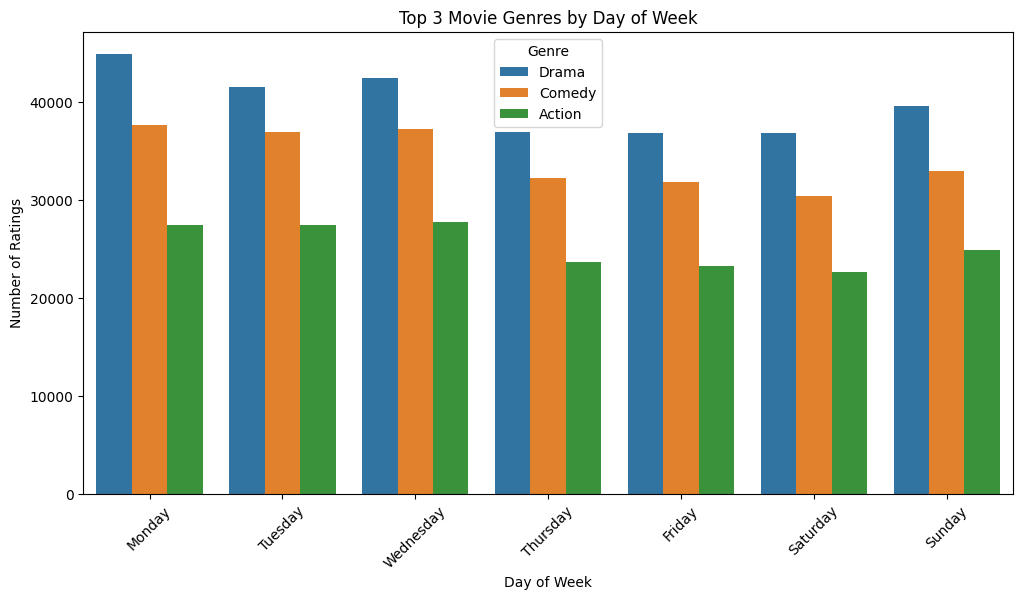

In [ ]:
# Top 3 genres per day

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

top3_pd["day_of_week"] = pd.Categorical(
    top3_pd["day_of_week"],
    categories=order,
    ordered=True
)

top3_pd = top3_pd.sort_values("day_of_week")



plt.figure(figsize=(12,6))
sns.barplot(data=top3_pd, x="day_of_week", y="num_ratings", hue="genre")

plt.xticks(rotation=45)
plt.xlabel("Day of Week")
plt.ylabel("Number of Ratings")
plt.title("Top 3 Movie Genres by Day of Week")

plt.legend(title="Genre")
plt.show()

To better understand genre popularity across different days, the top 3 genres per day were visualized.Unlike the initial result where Drama dominated, this visualization reveals that Comedy and Action are consistently among the most popular genres as well.
Although Drama remains the leading genre, user preferences show a stable pattern across the week, with no drastic variation between weekdays and weekends.

## What is the distribution of average ratings per user, and who are the most positive raters?

In [ ]:
# Average rating per user

user_avg = (
    ratings
    .groupBy("userId")
    .agg(avg("rating").alias("avg_rating"))
)

In [ ]:
user_avg_filtered = (
    ratings
    .groupBy("userId")
    .agg(
        avg("rating").alias("avg_rating"),
        count("*").alias("num_ratings")
    )
    .filter(col("num_ratings") > 50)
)

top_positive_users = (
    user_avg_filtered
    .orderBy(desc("avg_rating"))
    .limit(10)
)

top_positive_users.show()

+------+-----------------+-----------+
|userId|       avg_rating|num_ratings|
+------+-----------------+-----------+
|  2180|4.826923076923077|         52|
|  1809|4.803738317757009|        107|
|  3926|              4.8|        105|
|  2424|          4.65625|        192|
|  1562|4.636363636363637|        110|
|   168|4.633333333333334|        105|
|   617|4.617647058823529|         51|
|  4051|4.605263157894737|         95|
|  2408|              4.6|         75|
|  2713|4.589171974522293|        314|
+------+-----------------+-----------+



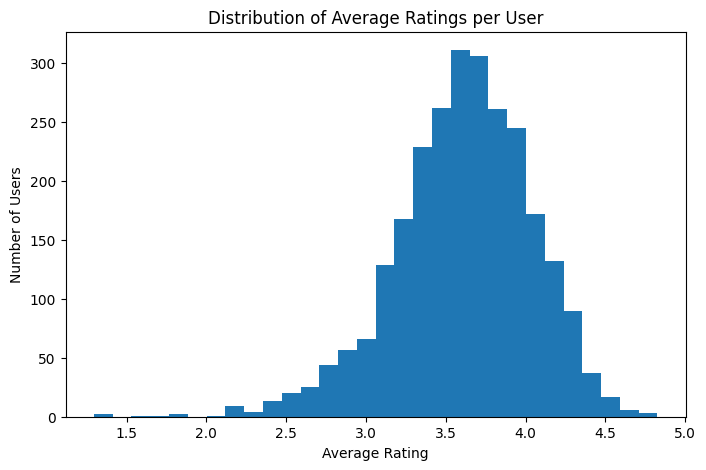

In [ ]:
# Distribution of user average ratings

user_avg_pd = user_avg_filtered.toPandas()

plt.figure(figsize=(8,5))
plt.hist(user_avg_pd["avg_rating"], bins=30)
plt.xlabel("Average Rating")
plt.ylabel("Number of Users")
plt.title("Distribution of Average Ratings per User")
plt.show()

To better understand user behavior, the distribution of average ratings per user was analyzed.
The histogram shows that most users have an average rating between 3.0 and 4.5, with a peak around 3.5–4.0. This indicates that users generally tend to give moderately high ratings rather than extreme low or high values.
Only a small number of users have very low or very high average ratings, suggesting that extreme rating behavior is relatively rare.
Overall, the distribution demonstrates that user ratings are fairly consistent and centered around positive values, reflecting a general tendency toward favorable evaluations in the dataset.

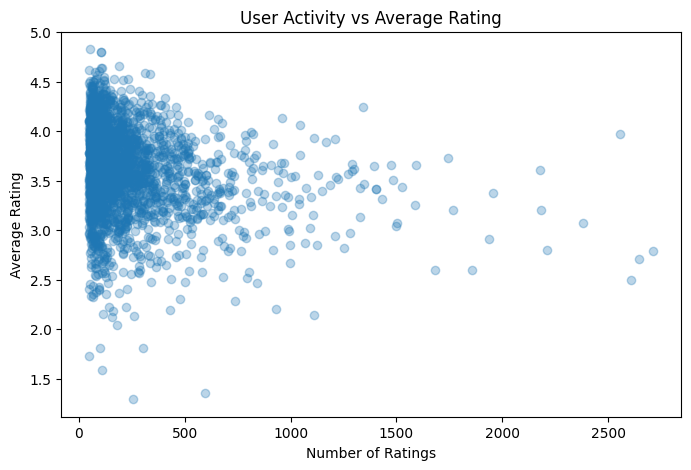

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(user_avg_pd["num_ratings"], user_avg_pd["avg_rating"], alpha=0.3)
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.title("User Activity vs Average Rating")
plt.show()

In [ ]:
# Join operation for execution plan analysis

join_default = ratings.join(movies, on="movieId", how="inner")

join_default.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [movieId#38, userId#37, rating#39, timestamp#40, day_of_week#187, title#18, genres#19]
   +- BroadcastHashJoin [movieId#38], [movieId#17], Inner, BuildRight, false
      :- Project [userId#37, movieId#38, rating#39, timestamp#40, date_format(timestamp#40, EEEE, Some(Etc/UTC)) AS day_of_week#187]
      :  +- Filter isnotnull(movieId#38)
      :     +- FileScan csv [userId#37,movieId#38,rating#39,timestamp#40] Batched: false, DataFilters: [isnotnull(movieId#38)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/content/rating.csv], PartitionFilters: [], PushedFilters: [IsNotNull(movieId)], ReadSchema: struct<userId:int,movieId:int,rating:double,timestamp:timestamp>
      +- BroadcastExchange HashedRelationBroadcastMode(List(cast(input[0, int, false] as bigint)),false), [plan_id=1276]
         +- Filter isnotnull(movieId#17)
            +- FileScan csv [movieId#17,title#18,genres#19] Batched: false, DataFilters: [is

For the join between ratings and movies, Spark used a BroadcastHashJoin.
In the physical plan, the movies DataFrame was broadcasted using BroadcastExchange, and Spark built the hash table on the right side (BuildRight). This happened because the movies dataset is much smaller than the ratings dataset.
Broadcasting the smaller table avoids expensive data shuffling and can make the join faster.

In [ ]:
# Disable automatic broadcast joins

spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

join_no_broadcast = ratings.join(movies, on="movieId", how="inner")

join_no_broadcast.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [movieId#38, userId#37, rating#39, timestamp#40, day_of_week#187, title#18, genres#19]
   +- SortMergeJoin [movieId#38], [movieId#17], Inner
      :- Sort [movieId#38 ASC NULLS FIRST], false, 0
      :  +- Exchange hashpartitioning(movieId#38, 200), ENSURE_REQUIREMENTS, [plan_id=1306]
      :     +- Project [userId#37, movieId#38, rating#39, timestamp#40, date_format(timestamp#40, EEEE, Some(Etc/UTC)) AS day_of_week#187]
      :        +- Filter isnotnull(movieId#38)
      :           +- FileScan csv [userId#37,movieId#38,rating#39,timestamp#40] Batched: false, DataFilters: [isnotnull(movieId#38)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/content/rating.csv], PartitionFilters: [], PushedFilters: [IsNotNull(movieId)], ReadSchema: struct<userId:int,movieId:int,rating:double,timestamp:timestamp>
      +- Sort [movieId#17 ASC NULLS FIRST], false, 0
         +- Exchange hashpartitioning(movieId#17, 200), ENSUR

After disabling automatic broadcast joins using spark.sql.autoBroadcastJoinThreshold = -1, Spark changed the join strategy from BroadcastHashJoin to SortMergeJoin.
In this physical plan, both DataFrames are shuffled using Exchange hashpartitioning and sorted by movieId before the join. This makes the operation more expensive because it requires data movement across partitions and sorting.
Compared to BroadcastHashJoin, SortMergeJoin can be slower for this case because the movies dataset is small enough to be broadcast efficiently. However, SortMergeJoin is more suitable when both datasets are large and broadcasting is not possible.

+----------------------------------+----------------+
|title                             |release_year_udf|
+----------------------------------+----------------+
|Toy Story (1995)                  |1995            |
|Jumanji (1995)                    |1995            |
|Grumpier Old Men (1995)           |1995            |
|Waiting to Exhale (1995)          |1995            |
|Father of the Bride Part II (1995)|1995            |
|Heat (1995)                       |1995            |
|Sabrina (1995)                    |1995            |
|Tom and Huck (1995)               |1995            |
|Sudden Death (1995)               |1995            |
|GoldenEye (1995)                  |1995            |
+----------------------------------+----------------+
only showing top 10 rows
PySpark UDF time: 0.1839 sec
+----------------------------------+-----------------------+
|title                             |release_year_pandas_udf|
+----------------------------------+-----------------------+
|Toy St

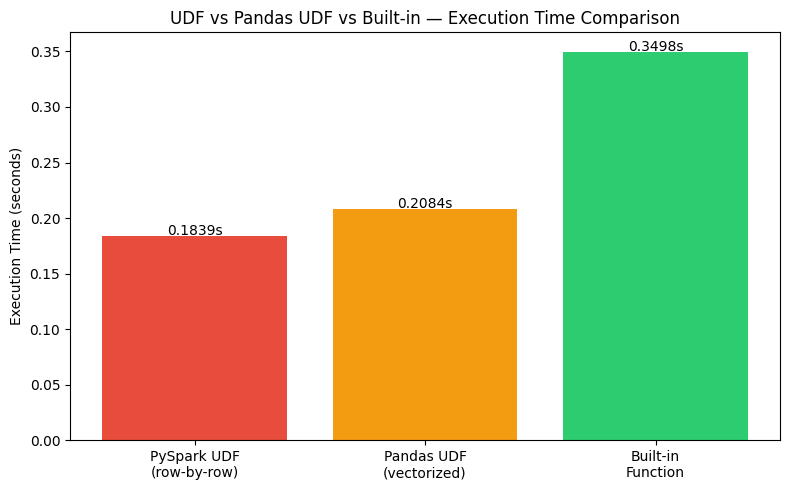

In [ ]:
from pyspark.sql.functions import udf, pandas_udf
from pyspark.sql.types import StringType
import pandas as pd
import time

# ── 1. PySpark UDF (row-by-row) ────────────────────────────────────────
def extract_year_python(title):
    import re
    if title is None:
        return None
    match = re.search(r"\((\d{4})\)", title)
    return match.group(1) if match else None

extract_year_udf = udf(extract_year_python, StringType())

start = time.time()
movies_udf = movies.withColumn("release_year_udf", extract_year_udf(col("title")))
_ = movies_udf.count()
udf_time = time.time() - start
movies_udf.select("title", "release_year_udf").show(10, truncate=False)
print(f"PySpark UDF time: {round(udf_time, 4)} sec")

# ── 2. Pandas UDF (vectorized) ─────────────────────────────────────────
@pandas_udf(StringType())
def extract_year_pandas_udf(titles: pd.Series) -> pd.Series:
    return titles.str.extract(r"\((\d{4})\)")[0]

start = time.time()
movies_pandas_udf = movies.withColumn("release_year_pandas_udf", extract_year_pandas_udf(col("title")))
_ = movies_pandas_udf.count()
pandas_udf_time = time.time() - start
movies_pandas_udf.select("title", "release_year_pandas_udf").show(10, truncate=False)
print(f"Pandas UDF time: {round(pandas_udf_time, 4)} sec")

# ── 3. Spark built-in ──────────────────────────────────────────────────
from pyspark.sql.functions import regexp_extract

start = time.time()
movies_builtin = movies.withColumn("release_year_builtin", regexp_extract(col("title"), r"\((\d{4})\)", 1))
_ = movies_builtin.count()
builtin_time = time.time() - start
movies_builtin.select("title", "release_year_builtin").show(10, truncate=False)
print(f"Built-in time: {round(builtin_time, 4)} sec")

# ── Visualization ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

methods = ["PySpark UDF\n(row-by-row)", "Pandas UDF\n(vectorized)", "Built-in\nFunction"]
times   = [udf_time, pandas_udf_time, builtin_time]
colors  = ["#e74c3c", "#f39c12", "#2ecc71"]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, times, color=colors)
plt.ylabel("Execution Time (seconds)")
plt.title("UDF vs Pandas UDF vs Built-in — Execution Time Comparison")
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.001,
             f"{round(t, 4)}s", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## Performance Comparison: PySpark UDF vs Pandas UDF vs Built-in Function

All three approaches were executed on Google Colab (Linux environment),
where native PySpark UDFs run correctly without worker crashes.
Execution time was measured using `.count()` action to trigger full Spark evaluation.

| Approach | Time | Execution Model |
|---|---|---|
| PySpark UDF | 0.1839s | Row-by-row Python |
| Pandas UDF | 0.2084s | Vectorized (Series) |
| Built-in | 0.3498s | Native JVM (cold start) |

**Note on results:** Built-in appears slowest here due to JVM cold start overhead
on the first execution. In production with warm JVM and large datasets,
built-in functions significantly outperform UDFs.

**PySpark UDF** processes each row individually with JVM → Python → JVM serialization.  
**Pandas UDF** operates on entire column batches (Series), reducing round trips.  
**Built-in** runs natively on the JVM — fastest at scale, but affected by cold start here.

Spark's Catalyst optimizer can push down and optimize built-in functions,
but treats UDF logic as a black box and cannot optimize it.
